# AG-HYPOPT · Trial 16

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Fifteen trials recorded, objective order: trial_09 0.1657 (BEST), trial_14 0.1679, trial_05 0.1863, trial_11 0.1883, trial_01 0.1907, trial_07 0.1940, trial_12 0.1941, trial_13 0.1941, trial_08 0.1948, trial_04 0.1987, trial_15 0.2046, trial_02 0.2075, trial_06 0.2203, trial_03 0.2472, trial_10 0.3727 (worst). Recap: mu_fit is pinned at ~half of mu_true for every config (objective floor); the objective is the gamma term, dominated by low transmission. The sweet spot is an interior band of high sigma_ref (~22-25), low-to-mid lr_mu (~5.5-8), high lr_gamma (~0.88-0.92) and moderate anneal (~0.41-0.62); its two best draws are trial_09/trial_14, but trial_15 in the same band collapsed at 1 nW Trans05, so the band is good on average but not robust. TPE (15/5) is exploiting. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_16'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (15/5 trials)
ID |     ei | params
 1 | 0.6112 | {"gamma_anneal": 0.675439803885932, "lr_gamma": 0.4784636403487964, "lr_mu": 16.6484405089709, "sigma_ref": 25.0}
 2 | 0.2444 | {"gamma_anneal": 0.6018157221494281, "lr_gamma": 0.7564991319188754, "lr_mu": 22.290493899581662, "sigma_ref": 25.0}
 3 | 2.7692 | {"gamma_anneal": 0.6635398268745084, "lr_gamma": 0.879571568071196, "lr_mu": 11.657716430253826, "sigma_ref": 24.6145779141935}
 4 | 1.2209 | {"gamma_anneal": 0.2885561338991415, "lr_gamma": 0.8363075613978413, "lr_mu": 13.763833633380969, "sigma_ref": 19.597697160933443}
 5 | 3.1615 | {"gamma_anneal": 0.5505848709786184, "lr_gamma": 0.9795992965392009, "lr_mu": 7.634924819981757, "sigma_ref": 25.0}
 6 | 2.2120 | {"gamma_anneal": 0.46914183726416814, "lr_gamma": 0.8495522606571663, "lr_mu": 18.110663077163043, "sigma_ref": 24.550104157057174}
 7 | 0.6736 | {"gamma_anneal": 0.7419022300167575, "lr_gamma": 0.8359981752683991, "lr_mu": 20.238566670778408, "sigma_ref": 5.

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (15/5) ranks by expected improvement. The highest-EI candidate is candidate 5 (EI 3.16): gamma_anneal 0.551, lr_gamma 0.980, lr_mu 7.63, sigma_ref 25.0. This sits inside the sweet-spot band (high sigma_ref at the 25.0 boundary, low-to-mid lr_mu, high lr_gamma, moderate anneal), continuing the region that produced the two best trials (trial_09/trial_14); lr_gamma 0.98 is a touch above the 0.88-0.92 band but well within tested values. The runner-ups (candidate 3: anneal 0.664, lr_mu 11.66; candidate 6: anneal 0.469, lr_mu 18.11) move lr_mu higher, which has been mid-pack. So the top-EI pick is the cleanest continuation of the sweet spot. I choose candidate 5.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5               # highest-EI TPE pick, inside the sweet spot


chosen: {'gamma_anneal': 0.5505848709786184, 'lr_gamma': 0.9795992965392009, 'lr_mu': 7.634924819981757, 'sigma_ref': 25.0}
Running  1nW Trans05 ... 

μ 9.39 -> 4.70 | γ 8.5 -> 2.16 | NLL 1.29


Running  1nW Trans20 ... 

μ 17.32 -> 8.67 | γ 8.5 -> 4.10 | NLL 2.91


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 51.11 | γ 14.1 -> 13.57 | NLL 3.22


Running 3nW Trans100 ... 

μ 175.71 -> 86.95 | γ 14.1 -> 13.97 | NLL 3.00



Total: 2.4 min


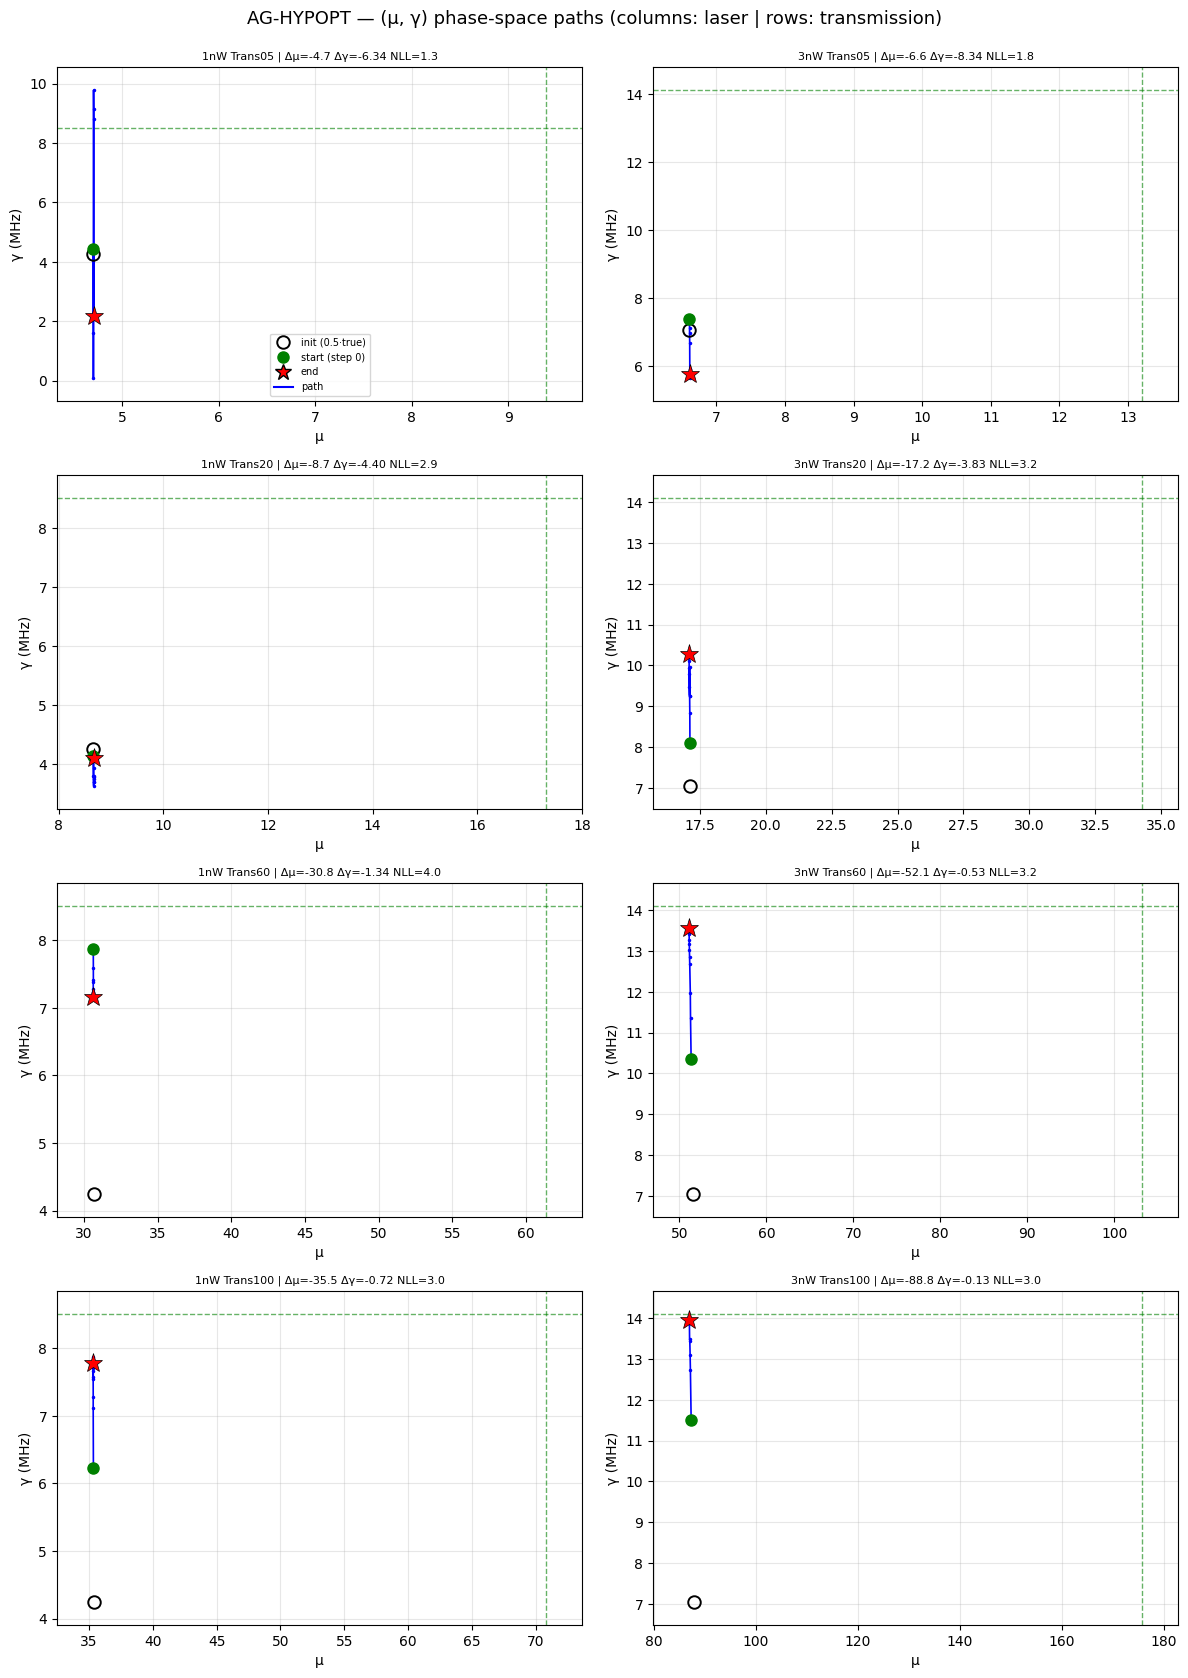

trial finished in 2.4 min
objective = 0.2058 ± 0.0375
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.70   -49.9 |     8.50    2.16   -74.6
1nW Trans20    17.32    8.67   -50.0 |     8.50    4.10   -51.8
1nW Trans60    61.37   30.61   -50.1 |     8.50    7.16   -15.8
1nW Trans100   70.82   35.34   -50.1 |     8.50    7.78    -8.5
3nW Trans05    13.20    6.62   -49.9 |    14.10    5.76   -59.2
3nW Trans20    34.28   17.09   -50.1 |    14.10   10.27   -27.1
3nW Trans60   103.20   51.11   -50.5 |    14.10   13.57    -3.7
3nW Trans100  175.71   86.95   -50.5 |    14.10   13.97    -0.9

μ: RMSE 40.668 (rel 50.1%, bias -30.524) | γ: RMSE 4.278 (rel 40.0%, bias -3.204)


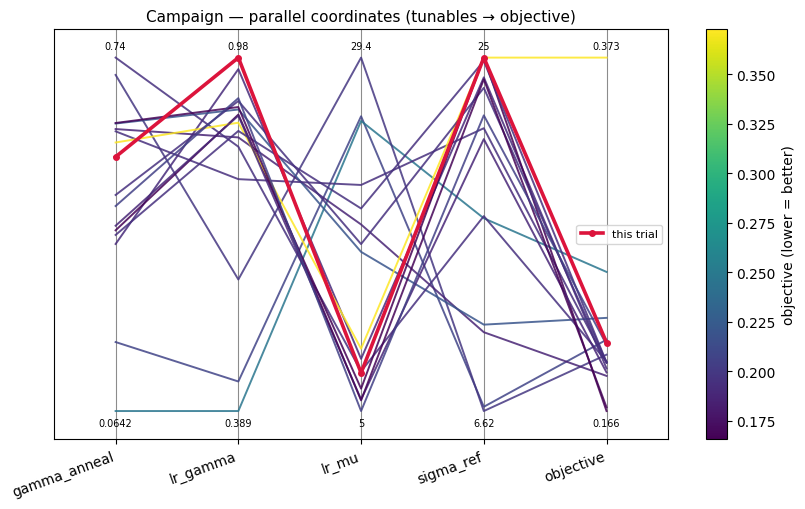

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 16, eleventh TPE-driven trial; highest-EI pick, inside the sweet-spot band: sigma_ref 25.0, lr_mu 7.63, lr_gamma 0.980, gamma_anneal 0.551. Result: objective 0.2058 +/- 0.0375, another mid-pack outcome (similar to trial_15 0.2046), well above the best; runtime 2.4 min. mu_fit is unchanged at a uniform ~half-truth (Delta-mu% -49.9 to -50.5; mu RMSE 40.67, relative 50.1%). gamma_fit: high/mid transmission fine (3 nW Trans60/100: -3.7/-0.9%; 1 nW Trans60 -15.8%) but low transmission degraded (1 nW Trans05 -74.6%, 1 nW Trans20 -51.8%; 3 nW Trans05 -59.2%), gamma RMSE 4.28 (relative 40.0%). So this sweet-spot-band config again failed to rescue the Trans05 gamma.

**Summary:** Trial 16 (sigma_ref 25.0, lr_mu 7.63, lr_gamma 0.980, gamma_anneal 0.551) -> objective 0.2058 +/- 0.0375, mid-pack; sweet-spot-band config but Trans05 gamma still collapsed (-75%/-59%).
**Key insight:** With trials 15 and 16, the sweet-spot band has now given two consecutive middling results after the two good ones (09/14) -- the band is favourable on average but the per-trial outcome is dominated by whether the low-transmission gamma happens to converge that run.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 16 (sigma_ref 25.0, lr_mu 7.63, lr_gamma 0.980, gamma_anneal 0.551): objective 0.2058 +/- 0.0375, mid-pack; sweet-spot-band config but Trans05 gamma still collapsed (-75%/-59%)'
KEY_INSIGHT = 'Trials 15 and 16 are two consecutive middling sweet-spot-band results after the two good ones (09/14): the band is favourable on average, but each trial score is dominated by whether the low-transmission gamma converges that run.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_16 | current best: trial_09


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_17.ipynb. Open it and follow its cells from the top.
